# EDA & Tiền xử lý — Communities and Crime (`communities.data`)

Bài toán **hồi quy**: dự đoán `ViolentCrimesPerPop` (tỉ lệ tội phạm bạo lực, đã chuẩn hoá [0,1]).
Bộ này **128 cột, gần như toàn số** — rất hợp để thực nghiệm **feature selection trên Linear Regression**
(nhiều feature, có cả feature yếu/nhiễu). Đặc thù: file `.data` **không có header** (lấy tên cột từ `.names`),
missing ký hiệu bằng **`?`**, và có vài cột định danh + nhiều cột thiếu rất nặng.

> ⚠️ Target `ViolentCrimesPerPop` giữ **nguyên gốc**, chỉ xử lý feature.

## 0. Thiết lập môi trường
Đặt thư mục làm việc chứa `communities.data` và `communities.names`.
> Chạy local thì bỏ phần `drive`/`os.chdir`.

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/AIO-Conquer02')
os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/AIO-Conquer02'

## 1. Nạp dữ liệu — lấy tên cột từ `.names`

**Lý do:** `communities.data` không có header; tên 128 cột nằm trong các dòng `@attribute` của `communities.names`.
Đọc kèm `na_values='?'` để pandas hiểu ô thiếu.

In [2]:
import pandas as pd
import numpy as np
import re

# Lấy tên cột từ các dòng '@attribute <ten> <kieu>' trong file .names
BASE = 'communities+and+crime/'   # chỉnh nếu bạn đặt 2 file ở thư mục khác
names = []
with open(BASE + 'communities.names', encoding='latin-1') as f:
    for line in f:
        m = re.match(r'@attribute\s+(\S+)\s+(\S+)', line.strip(), re.I)
        if m:
            names.append(m.group(1))
print('Số cột đọc được từ .names:', len(names))

df = pd.read_csv(BASE + 'communities.data', header=None, names=names, na_values='?')
df.info(verbose=False)
print('Target:', names[-1])

Số cột đọc được từ .names: 128
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(125), int64(2), object(1)
memory usage: 1.9+ MB
Target: ViolentCrimesPerPop


> 📊 **Phân tích:** **1.994 dòng × 128 cột**, gần như toàn `float64` (đã chuẩn hoá [0,1]); chỉ `communityname` là chuỗi.
> Target `ViolentCrimesPerPop` (cột cuối). 5 cột đầu là **định danh/không dự đoán**: `state`, `county`, `community`,
> `communityname`, `fold` (cột `fold` chỉ là chỉ số chia CV).

## 2. Cleaning bước 1 — bỏ cột định danh

**Lý do:** `state`, `county`, `community`, `communityname`, `fold` không phải đặc trưng dự đoán
(định danh hành chính / chỉ số fold) → bỏ để tránh nhiễu cho selection.

In [3]:
id_cols = ['state', 'county', 'community', 'communityname', 'fold']
df = df.drop(columns=[c for c in id_cols if c in df.columns])
print('Sau khi bỏ định danh:', df.shape)

Sau khi bỏ định danh: (1994, 123)


> 📊 **Phân tích:** Còn **123 cột** (122 feature + target). Tất cả còn lại đều là biến số đã chuẩn hoá.

## 3. Phân tích missing

**Lý do:** Bộ này thiếu rất nặng và **lệch hẳn về một nhóm cột** → cần đo tỉ lệ thiếu để quyết bỏ cột hay điền.

Số cột có missing: 23
Số cột thiếu > 50%: 22


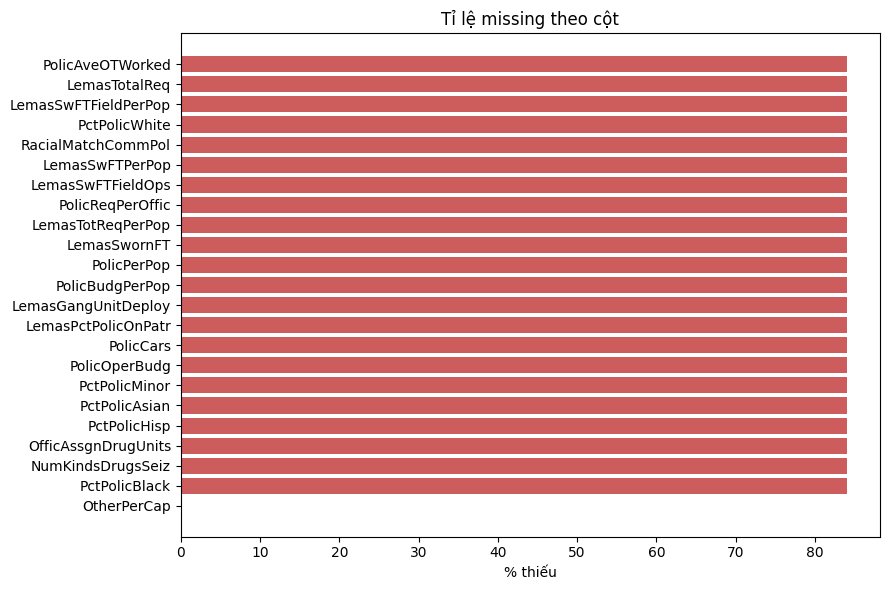

,pct_missing
PolicAveOTWorked,84.0
LemasTotalReq,84.0
LemasSwFTFieldPerPop,84.0
PctPolicWhite,84.0
RacialMatchCommPol,84.0
LemasSwFTPerPop,84.0
LemasSwFTFieldOps,84.0
PolicReqPerOffic,84.0
LemasTotReqPerPop,84.0
LemasSwornFT,84.0


In [4]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print('Số cột có missing:', len(miss))
print('Số cột thiếu > 50%:', int((miss > 0.5).sum()))
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.barh(miss.index[::-1], (miss * 100)[::-1], color='indianred')
plt.xlabel('% thiếu'); plt.title('Tỉ lệ missing theo cột'); plt.tight_layout(); plt.show()
(miss * 100).round(1).to_frame('pct_missing')

> 📊 **Phân tích:** **25 cột có missing**, trong đó **22 cột thiếu >50%** — thực chất ~**84%** (1.675/1.994), gần như toàn
> nhóm chỉ số cảnh sát (`LemasSwornFT`, `PolicPerPop`, `PolicBudgPerPop`, `RacialMatchCommPol`...). Điền cho cột thiếu 84%
> là **bịa dữ liệu** → nên **bỏ hẳn**. Còn lại chỉ `OtherPerCap` thiếu **1 ô** → điền median. Target **không thiếu**.

## 4. Cleaning bước 2 — bỏ cột thiếu nặng & điền phần thiếu lẻ

**Lý do:** Bỏ các cột thiếu >50% (không cứu được), điền median cho phần thiếu nhỏ còn lại (robust với lệch).
**Không** đụng target.

In [5]:
TARGET = 'ViolentCrimesPerPop'

# (a) bỏ cột thiếu > 50%
hi_missing = [c for c in df.columns if df[c].isna().mean() > 0.5]
df_clean = df.drop(columns=hi_missing)

# (b) điền median cho feature còn thiếu (trừ target)
feat = [c for c in df_clean.columns if c != TARGET]
df_clean[feat] = df_clean[feat].fillna(df_clean[feat].median())

print('Đã bỏ', len(hi_missing), 'cột thiếu >50%')
print('Shape sau cleaning:', df_clean.shape, '| missing còn:', int(df_clean.isna().sum().sum()))

Đã bỏ 22 cột thiếu >50%
Shape sau cleaning: (1994, 101) | missing còn: 0


> 📊 **Phân tích:** Còn **1.994 × 101** (100 feature + target), **0 missing**. Bộ đặc trưng giờ gọn, toàn số chuẩn hoá [0,1].

## 5. Phân phối target & vài feature

**Lý do:** Xem hình dạng target (đã chuẩn hoá) và độ lệch một số feature.

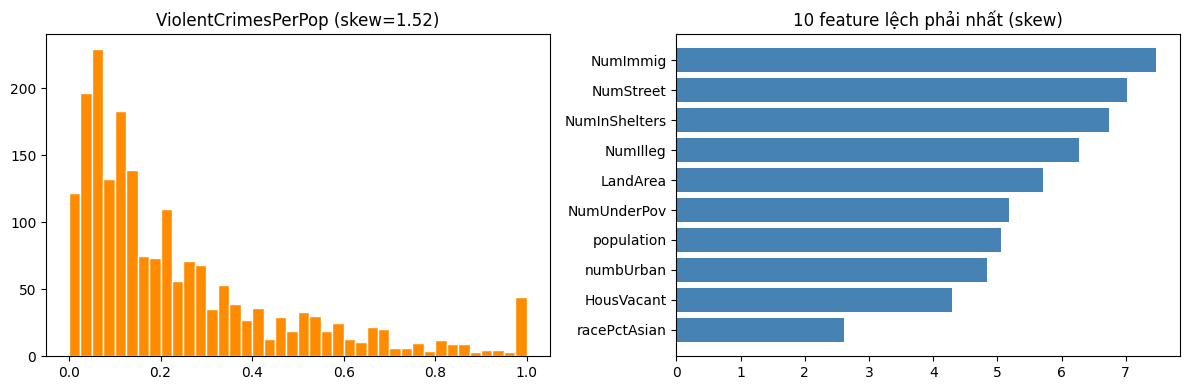

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df_clean[TARGET], bins=40, color='darkorange', edgecolor='white')
ax[0].set_title(f'{TARGET} (skew={df_clean[TARGET].skew():.2f})')
sk = df_clean.drop(columns=[TARGET]).skew().sort_values(ascending=False)
ax[1].barh(sk.index[:10][::-1], sk.values[:10][::-1], color='steelblue')
ax[1].set_title('10 feature lệch phải nhất (skew)')
plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Target lệch phải (nhiều cộng đồng tội phạm thấp, đuôi cao thưa). Vì mọi biến đã **chuẩn hoá [0,1]**
> nên không cần scale lại; một số feature vẫn lệch nhưng nằm trong [0,1] nên ảnh hưởng nhẹ.

## 6. Tương quan với target

**Lý do:** Xếp hạng |Pearson| để xem feature nào mạnh — và quan trọng cho thí nghiệm: có bao nhiêu feature **yếu/gần nhiễu**.

Top 10 |corr| mạnh nhất:
PctKids2Par        -0.738
PctIlleg            0.738
PctFam2Par         -0.707
racePctWhite       -0.685
PctYoungKids2Par   -0.666
PctTeen2Par        -0.662
racepctblack        0.631
pctWInvInc         -0.576
pctWPubAsst         0.575
FemalePctDiv        0.556
Name: ViolentCrimesPerPop, dtype: float64

Số feature |corr| < 0.1 (yếu, gần nhiễu): 18 / 100


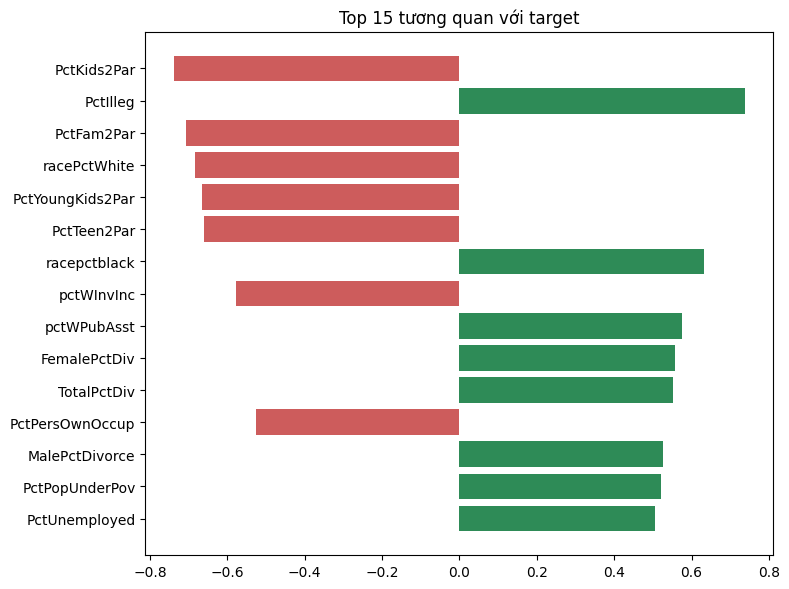

In [7]:
corr_t = df_clean.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
print('Top 10 |corr| mạnh nhất:')
print(corr_t.head(10).round(3))
print('\nSố feature |corr| < 0.1 (yếu, gần nhiễu):', int((corr_t.abs() < 0.1).sum()), '/', len(corr_t))
plt.figure(figsize=(8, 6))
top = corr_t.head(15)
plt.barh(top.index[::-1], top.values[::-1], color=['seagreen' if v>0 else 'indianred' for v in top.values[::-1]])
plt.title('Top 15 tương quan với target'); plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Mạnh nhất: **`PctKids2Par` (0,74)**, **`PctIlleg` (0,74)**, `PctFam2Par` (0,71), `racePctWhite` (0,69) —
> cấu trúc gia đình & nhân khẩu. Đáng chú ý cho thí nghiệm: **~18/100 feature có |corr|<0,1** (yếu, gần nhiễu) → đây chính là
> phần selection có thể loại để giúp Linear Regression. → **bộ này rất hợp** để đo impact của Lasso/RFE.

## 7. Lưu dữ liệu đã xử lý

**Lý do:** Xuất bộ sạch: bỏ định danh + cột thiếu nặng, điền phần thiếu lẻ, giữ target nguyên gốc, feature đã chuẩn hoá sẵn.
Lưu `communities_processed.csv`.

In [8]:
df_clean.to_csv('communities_processed.csv', index=False)
print('Đã lưu communities_processed.csv |', df_clean.shape, '| missing:', int(df_clean.isna().sum().sum()))
df_clean.head()

Đã lưu communities_processed.csv | (1994, 101) | missing: 0


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03


> 💾 **Kết quả:** `communities_processed.csv` — **1.994 × 101** (100 feature + target), 0 missing, feature ∈ [0,1], target nguyên gốc.
>
> **Sẵn cho thí nghiệm selection:** 100 feature số, có ~18 feature yếu/nhiễu → so sánh **Linear Regression full vs Lasso vs RFE**
> (đo R² test + số feature giữ lại). Feature đã chuẩn hoá nên có thể bỏ qua scaling, nhưng vẫn nên `StandardScaler` cho Lasso để phạt công bằng.